In [1]:
!pip install albumentations==1.4.3 opencv-python-headless==4.10.0.84 segmentation-models-pytorch kagglehub
!pip install -q kaggle
!pip install scikit-image

import sys, subprocess, importlib

print("Python executable:", sys.executable)
print("Python version:", sys.version)

subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])

skimage = importlib.import_module("skimage")
from skimage import transform
print("skimage.transform OK")

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch import nn
import os
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import kagglehub

Python executable: C:\Users\Katsumi\AppData\Local\Programs\Python\Python39\python.exe
Python version: 3.9.2 (tags/v3.9.2:1a79785, Feb 19 2021, 13:44:55) [MSC v.1928 64 bit (AMD64)]
skimage.transform OK


C:\Users\Katsumi\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# python
import os
import json
from pathlib import Path

# use the directory you specified as the .kaggle folder
kaggle_dir = Path(r'D:\8086\processamento_imagems\.kaggle')
kaggle_file = kaggle_dir / "kaggle.json"

try:
    with kaggle_file.open("r", encoding="utf-8") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds.get("username", "")
    os.environ["KAGGLE_KEY"] = creds.get("key", "")
    if os.environ["KAGGLE_USERNAME"] and os.environ["KAGGLE_KEY"]:
        print("Kaggle credentials set from", str(kaggle_file))
    else:
        print("Credentials file found but missing `username` or `key` in", str(kaggle_file))
except FileNotFoundError:
    print("Kaggle credentials file not found at", str(kaggle_file))
except json.JSONDecodeError:
    print("Malformed JSON in", str(kaggle_file))
except Exception as e:
    print("Failed to load Kaggle credentials:", e)


Kaggle credentials set from D:\8086\processamento_imagems\.kaggle\kaggle.json


In [3]:
# python
import os
import sys
import subprocess
from pathlib import Path
import zipfile

zip_path = Path("river-water-segmentation-dataset.zip")
extract_dir = Path("river-water-segmentation-dataset")

if extract_dir.exists():
    print("Dataset already extracted at", extract_dir)
else:
    if not zip_path.exists():
        print("Downloading dataset...")
        try:
            subprocess.check_call(["kaggle", "datasets", "download", "-d", "franzwagner/river-water-segmentation-dataset"])
        except FileNotFoundError:
            # fallback to running kaggle as a module if the script isn't on PATH
            subprocess.check_call([sys.executable, "-m", "kaggle", "datasets", "download", "-d", "franzwagner/river-water-segmentation-dataset"])
    else:
        print("Found existing zip:", zip_path)

    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    print("Extracted to", extract_dir)


Dataset already extracted at river-water-segmentation-dataset


In [4]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

class RiverDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = [f for f in os.listdir(image_dir) if f.lower().endswith(VALID_EXTENSIONS)]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        base_name, _ = os.path.splitext(img_name)
        mask_name = base_name + ".png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image file not found or is unreadable at: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask file not found or is unreadable at: {mask_path}")

        _, mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY_INV)

        mask = mask / 255.0

        mask = np.expand_dims(mask, axis=-1)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask
    
    # device = "cuda" if torch.cuda.is_available() else "cpu"
# model = UNet().to(device)
# model.load_state_dict(torch.load("unet_river.pth", map_location=device))
# model.eval()

import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model.to(device)

print("carregado")

carregado


In [5]:
# --- Define Transforms ---
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]
IMG_HEIGHT, IMG_WIDTH = 256, 256

train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Rotate(limit=35, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(transpose_mask=True), # Correctly transposes mask
])

val_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(transpose_mask=True),
])

# --- Define dataset root path ---
# 'path' variable comes from your download cell (Cell 2)
dataset_root = Path("river-water-segmentation-dataset") / "riwa_v2"

TRAIN_IMG_DIR = dataset_root / "images"
TRAIN_MASK_DIR = dataset_root / "masks"
VAL_IMG_DIR = dataset_root / "validation" / "images"
VAL_MASK_DIR = dataset_root / "validation" / "masks"


# --- Create Datasets and DataLoaders ---
train_dataset = RiverDataset(
    image_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    transform=train_transform
)

# Now we create the validation dataset
val_dataset = RiverDataset(
    image_dir=VAL_IMG_DIR,
    mask_dir=VAL_MASK_DIR,
    transform=val_transform
)

# Create the DataLoaders
BATCH_SIZE = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# --- Test if it works ---
print("Testing DataLoaders...")
images, masks = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape: {masks.shape}")

images_val, masks_val = next(iter(val_loader))
print(f"Val Image batch shape: {images_val.shape}")
print(f"Val Mask batch shape: {masks_val.shape}")
print("✅ Train and Validation DataLoaders created.")

Testing DataLoaders...
Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Val Image batch shape: torch.Size([8, 3, 256, 256])
Val Mask batch shape: torch.Size([8, 1, 256, 256])
✅ Train and Validation DataLoaders created.


In [6]:
# import torch.optim as optim
# import segmentation_models_pytorch as smp
# from tqdm import tqdm # For a nice progress bar
# 
# # --- Parameters ---
# LEARNING_RATE = 1e-4
# NUM_EPOCHS = 10 # Start with 25, you can increase this if needed
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# 
# # --- Define Model ---
# model = smp.Unet(
#     encoder_name="resnet34",
#     encoder_weights="imagenet",
#     in_channels=3,
#     classes=1,
# )
# model.to(DEVICE)
# 
# # --- Loss Function & Optimizer ---
# loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scaler = torch.cuda.amp.GradScaler() # For mixed precision (faster training)
# 
# # --- Main Training & Validation Loop ---
# print("Starting training...")
# best_val_loss = float('inf') # Save the model with the best *validation* loss
# 
# for epoch in range(NUM_EPOCHS):
#     print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
# 
#     # --- Training Phase ---
#     model.train()
#     train_loss = 0.0
#     train_loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False)
# 
#     for batch_idx, (data, targets) in enumerate(train_loop):
#         data = data.to(device=DEVICE)
#         targets = targets.to(device=DEVICE, dtype=torch.float32)
# 
#         with torch.cuda.amp.autocast():
#             predictions = model(data)
#             loss = loss_fn(predictions, targets)
# 
#         optimizer.zero_grad()
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
# 
#         train_loss += loss.item()
#         train_loop.set_postfix(loss=loss.item())
# 
#     avg_train_loss = train_loss / len(train_loader)
#     print(f"Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}")
# 
#     # --- Validation Phase ---
#     model.eval()
#     val_loss = 0.0
#     val_loop = tqdm(val_loader, desc=f"Valid Epoch {epoch+1}", leave=False)
# 
#     with torch.no_grad():
#         for data, targets in val_loop:
#             data = data.to(device=DEVICE)
#             targets = targets.to(device=DEVICE, dtype=torch.float32)
# 
#             with torch.cuda.amp.autocast():
#                 predictions = model(data)
#                 loss_val = loss_fn(predictions, targets)
# 
#             val_loss += loss_val.item()
#             val_loop.set_postfix(val_loss=loss_val.item())
# 
#     avg_val_loss = val_loss / len(val_loader)
#     print(f"Epoch {epoch+1} Avg Val Loss:   {avg_val_loss:.4f}")
# 
#     # --- Save the best model based on validation loss ---
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model.state_dict(), "best_model.pth")
#         print(f"==> Validation Loss improved! Saving new best_model.pth")
# 
# print("\n🎉 Training finished!")

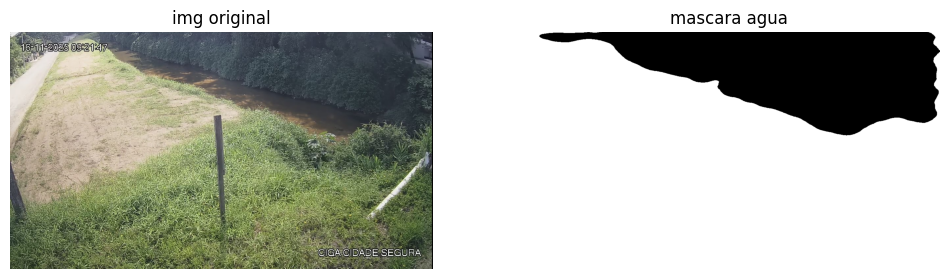

In [7]:
import matplotlib.pyplot as plt


model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # We don't need imagenet weights, we'll load our own
    in_channels=3,
    classes=1,
)
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval() # Set model to evaluation mode!


IMG_HEIGHT, IMG_WIDTH = 256, 256
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])

img_path = Path(r'D:\8086\processamento_imagems\dataset\img_flood\rio.jpg')

img_rgb = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

aug = transform(image=img_rgb)
img_tensor = aug["image"].unsqueeze(0).to(device)


with torch.no_grad():
    pred = torch.sigmoid(model(img_tensor))[0,0].cpu().numpy()

orig_h, orig_w, _ = img_rgb.shape
pred_resized = cv2.resize(pred, (orig_w, orig_h))
mask = (pred_resized > 0.5).astype(np.uint8) * 255

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("img original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("mascara agua")
plt.axis("off")
plt.show()